In [ ]:
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import joblib

import matplotlib.pyplot as plt

In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download("hayaalwizrah1/gold-price-prediction-dataset-20002026")
data = pd.read_csv(os.path.join(path, 'gold_data.csv'))

100%|██████████| 941k/941k [00:00<00:00, 95.6MB/s]

Extracting files...


In [ ]:
df = pd.DataFrame(data=data)
df.head()

,Date,Gold_Open,Gold_High,Gold_Low,Gold_Close,Gold_Volume,DXY,SP500,Oil,VIX,...,Daily_Return,RSI,MACD,MACD_Signal,MACD_Hist,BB_Upper,BB_Middle,BB_Lower,ATR,Target
0,2000-10-18,270.299988,270.299988,270.299988,270.299988,0.0,117.330002,1342.130005,33.549999,28.719999,...,-0.002951,44.027677,-0.811933,-0.890278,0.078346,277.007532,272.364998,267.722464,1.797421,270.100006
1,2000-10-19,270.100006,270.100006,270.100006,270.100006,1.0,116.940002,1388.760010,32.950001,25.090000,...,-0.000740,43.589968,-0.887787,-0.889780,0.001993,277.016104,272.354999,267.693893,1.683319,271.200012
2,2000-10-20,271.200012,271.200012,271.200012,271.200012,32.0,117.160004,1396.930054,34.299999,24.240000,...,0.004073,46.727258,-0.849350,-0.881694,0.032344,277.007681,272.325000,267.642319,1.641653,270.100006
3,2000-10-23,271.700012,271.700012,270.100006,270.100006,1.0,117.540001,1395.780029,33.730000,24.690001,...,-0.004056,44.086729,-0.897306,-0.884817,-0.012490,276.828986,272.125000,267.421014,1.638679,270.100006
4,2000-10-24,269.799988,270.100006,269.799988,270.100006,16.0,117.419998,1398.130005,33.369999,24.280001,...,0.000000,44.086729,-0.924653,-0.892784,-0.031869,276.643831,271.935001,267.226170,1.543060,266.200012


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

In [ ]:
print("Data Types:", data.dtypes)

Data Types: Date             object
Gold_Open       float64
Gold_High       float64
Gold_Low        float64
Gold_Close      float64
Gold_Volume     float64
DXY             float64
SP500           float64
Oil             float64
VIX             float64
Lag1            float64
Lag7            float64
MA7             float64
MA30            float64
EMA20           float64
Daily_Return    float64
RSI             float64
MACD            float64
MACD_Signal     float64
MACD_Hist       float64
BB_Upper        float64
BB_Middle       float64
BB_Lower        float64
ATR             float64
Target          float64
dtype: object


In [ ]:

X = df.drop(
    columns=["Date", "Target", "Lag1", "Gold_Close", "Daily_Return"], axis=1
)
y = df["Target"]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6468 entries, 0 to 6467
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          6468 non-null   datetime64[ns]
 1   Gold_Open     6468 non-null   float64       
 2   Gold_High     6468 non-null   float64       
 3   Gold_Low      6468 non-null   float64       
 4   Gold_Close    6468 non-null   float64       
 5   Gold_Volume   6468 non-null   float64       
 6   DXY           6468 non-null   float64       
 7   SP500         6468 non-null   float64       
 8   Oil           6468 non-null   float64       
 9   VIX           6468 non-null   float64       
 10  Lag1          6468 non-null   float64       
 11  Lag7          6468 non-null   float64       
 12  MA7           6468 non-null   float64       
 13  MA30          6468 non-null   float64       
 14  EMA20         6468 non-null   float64       
 15  Daily_Return  6468 non-null   float64 

In [ ]:

print("Summary Statistics:", data.describe())

Summary Statistics:          Gold_Open    Gold_High     Gold_Low   Gold_Close    Gold_Volume  \
count  6468.000000  6468.000000  6468.000000  6468.000000    6468.000000   
mean   1331.326408  1338.590121  1323.732607  1331.278663    4289.251237   
std     874.129231   880.732577   866.927261   873.866684   23983.824104   
min     255.000000   256.100006   255.000000   255.100006       0.000000   
25%     662.500000   665.200012   660.724991   662.500000      24.000000   
50%    1258.549988  1265.600037  1253.450012  1258.400024     121.000000   
75%    1719.375031  1728.325043  1708.950012  1719.925049     467.000000   
max    5415.700195  5586.200195  5301.600098  5318.399902  386334.000000   

               DXY        SP500          Oil          VIX         Lag1  ...  \
count  6468.000000  6468.000000  6468.000000  6468.000000  6468.000000  ...   
mean     92.508420  2405.750051    65.248230    19.743652  1330.686672  ...   
std      11.006872  1619.893786    24.513317     8.392199 

In [14]:


X = df.drop(
    columns=["Date", "Target", "Lag1", "Gold_Close", "Daily_Return"]
)

y = df["Target"]

n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
X_val = X.iloc[train_end:val_end]
X_test = X.iloc[val_end:]

y_train = y.iloc[:train_end]
y_val = y.iloc[train_end:val_end]
y_test = y.iloc[val_end:]

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (4527, 20)
Validation set: (970, 20)
Test set: (971, 20)


In [15]:
# Scale features using only the training data

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(
    y_train.values.reshape(-1, 1)
)

y_val_scaled = scaler_y.transform(
    y_val.values.reshape(-1, 1)
)

y_test_scaled = scaler_y.transform(
    y_test.values.reshape(-1, 1)
)

# Save scalers
joblib.dump(scaler_X, "scaler_X.pkl")
joblib.dump(scaler_y, "scaler_y.pkl")

['scaler_y.pkl']

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

model = Sequential([

    Dense(64, activation='relu', kernel_regularizer=l2(0.01), input_shape=(X_train.shape[1],)),
    Dropout(0.35),


    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.35),


    Dense(1, activation='linear')
])


optimizer = Adam(learning_rate=0.0003)

model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_gold_model.keras",
    monitor="val_loss",
    save_best_only=True
)

history = model.fit(
    X_train_scaled,
    y_train_scaled,

    validation_data=(
        X_val_scaled,
        y_val_scaled
    ),

    epochs=150,
    batch_size=32,

    callbacks=[
        early_stop,
        checkpoint
    ],

    verbose=1
)

Epoch 1/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.2854 - mae: 0.5578 - val_loss: 0.7700 - val_mae: 0.2359
Epoch 2/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9253 - mae: 0.3950 - val_loss: 0.7202 - val_mae: 0.2613
Epoch 3/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8002 - mae: 0.3413 - val_loss: 0.6436 - val_mae: 0.2323
Epoch 4/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7035 - mae: 0.2998 - val_loss: 0.6074 - val_mae: 0.2607
Epoch 5/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6341 - mae: 0.2821 - val_loss: 0.5934 - val_mae: 0.3169
Epoch 6/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5679 - mae: 0.2576 - val_loss: 0.4898 - val_mae: 0.2134
Epoch 7/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5173 - mae: 0.2477 - val_loss: 0.4669 - val_mae: 0.2481
Epoch 8/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4701 - mae: 0.2347 - val_loss: 0.4460 - val_mae: 0.2762
Epoch 9/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/

In [23]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,373 (40.52 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,916 (27.02 KB)

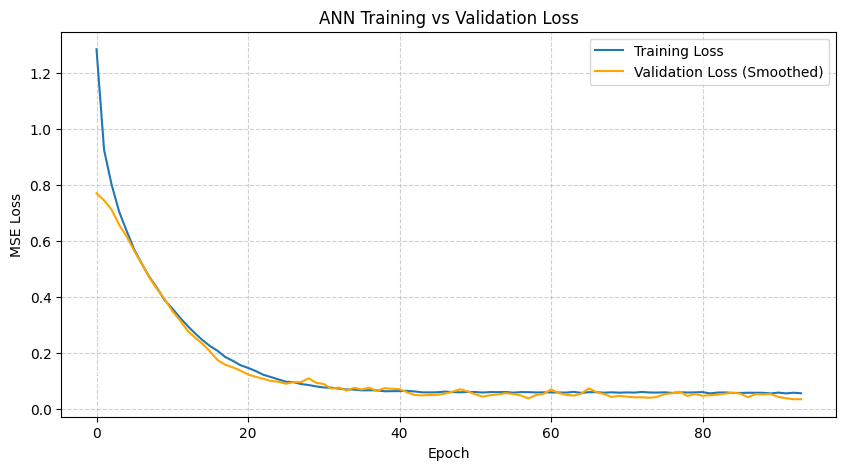

In [24]:
import matplotlib.pyplot as plt
import pandas as pd


val_loss_smoothed = pd.Series(history.history['val_loss']).rolling(window=3, min_periods=1).mean()
train_loss = history.history['loss']

plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss_smoothed, label='Validation Loss (Smoothed)', color='orange')
plt.title('ANN Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [26]:
y_pred_scaled = model.predict(X_test_scaled)

print("y_test_scaled:", y_test_scaled.shape)
print("y_pred_scaled:", y_pred_scaled.shape)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_test_scaled: (971, 1)
y_pred_scaled: (971, 1)


In [29]:
y_pred_scaled = model.predict(X_test_scaled)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [34]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test_actual, y_pred_actual) * 100
print(f"MAPE: {mape:.2f}%")

MAPE: 5.18%


In [36]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_actual = scaler_y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test_scaled)


mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2 = r2_score(y_test_actual, y_pred_actual)


print("Model Evaluation Results (ANN):")
print(f"- Mean Absolute Error (MAE): ${mae:.2f}")
print(f"- Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"- R-squared (R²) Score: {r2 * 100:.2f}%")

Model Evaluation Results (ANN):
- Mean Absolute Error (MAE): $158.93
- Root Mean Squared Error (RMSE): $190.22
- R-squared (R²) Score: 96.39%


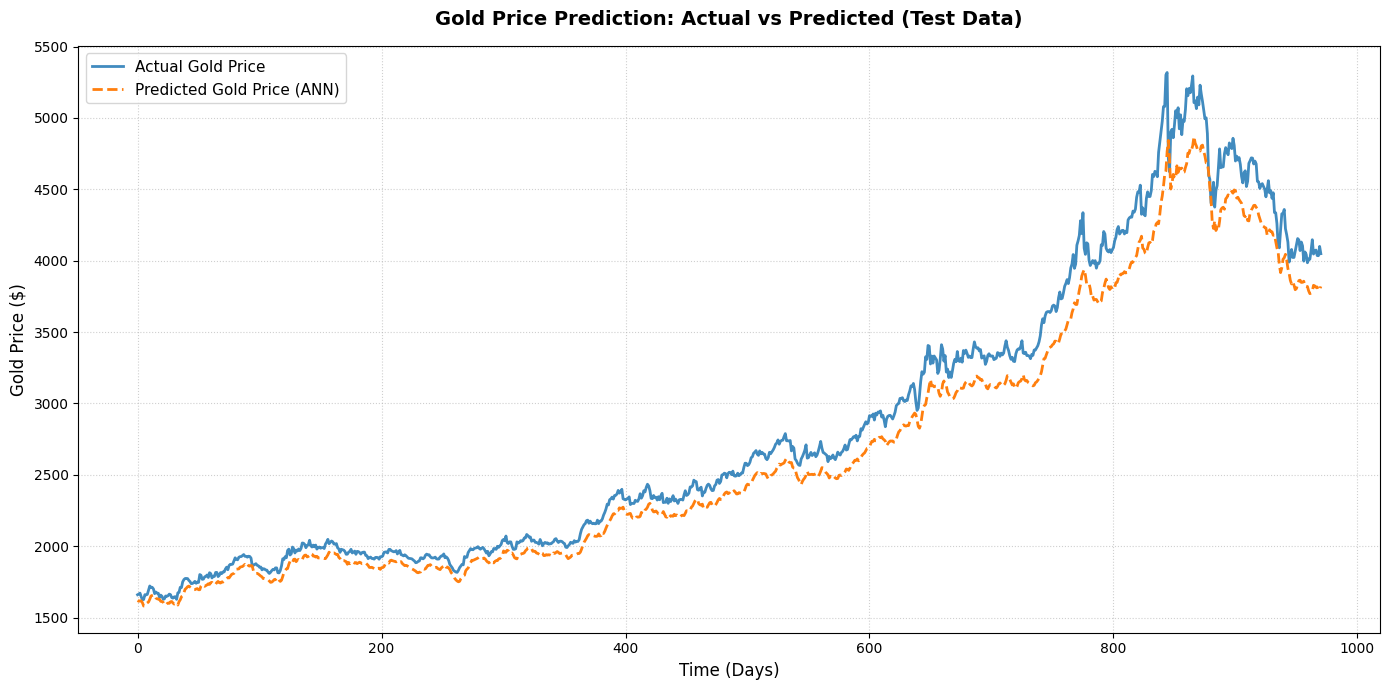

In [37]:
import matplotlib.pyplot as plt


plt.figure(figsize=(14, 7))

plt.plot(y_test_actual, label='Actual Gold Price', color='#1f77b4', linewidth=2, alpha=0.85)
plt.plot(y_pred_actual, label='Predicted Gold Price (ANN)', color='#ff7f0e', linestyle='--', linewidth=2)


plt.title('Gold Price Prediction: Actual vs Predicted (Test Data)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Time (Days)', fontsize=12)
plt.ylabel('Gold Price ($)', fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)


plt.tight_layout()
plt.show()

In [38]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.1 MB/s eta 0:00:00


In [60]:
import keras_tuner as kt
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2


def build_model(hp):
  model = Sequential()

  # 1. ضبط عدد خلايا الطبقة الأولى
  hp_units_1 = hp.Int('units_1', min_value=32, max_value=128, step=32)
  model.add(
      Dense(
          units=hp_units_1,
          activation='relu',
          kernel_regularizer=l2(0.001),
          input_shape=(X_train.shape[1],),
      )
  )

  hp_dropout = hp.Float('dropout', min_value=0.1, max_value=0.3, step=0.1)
  model.add(Dropout(rate=hp_dropout))


  hp_units_2 = hp.Int('units_2', min_value=16, max_value=64, step=16)
  model.add(
      Dense(units=hp_units_2, activation='relu', kernel_regularizer=l2(0.001))
  )
  model.add(Dropout(rate=hp_dropout))

  model.add(Dense(1, activation='linear'))

  hp_learning_rate = hp.Choice(
      'learning_rate', values=[0.001, 0.0005, 0.0001]
  )

  model.compile(
      optimizer=Adam(learning_rate=hp_learning_rate),
      loss='mse',
      metrics=['mae'],
  )

  return model

In [61]:
# إعداد الـ Tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=5,
    executions_per_trial=1,
    directory='my_dir',
    project_name='gold_price_tuning_v2',
    overwrite=True,
)

tuner.search(
    X_train,
    y_train,
    epochs=50,
    validation_data=(X_val, y_val),
    batch_size=32,
    callbacks=[early_stop],
)

Trial 5 Complete [00h 00m 11s]
val_loss: 36142.890625

Best val_loss So Far: 8658.2705078125
Total elapsed time: 00h 01m 06s


In [74]:

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
model = tuner.hypermodel.build(best_hps)


history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    callbacks=[early_stop]
)


model.save("gold_price_ann_model.h5")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5308546.5000 - mae: 554.7813 - val_loss: 538454.3125 - val_mae: 289.2814
Epoch 2/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2978309.2500 - mae: 428.6554 - val_loss: 136999.6719 - val_mae: 206.9392
Epoch 3/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2515083.2500 - mae: 361.9572 - val_loss: 23735.2090 - val_mae: 93.8465
Epoch 4/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1426193.7500 - mae: 311.3298 - val_loss: 14034.5117 - val_mae: 97.8733
Epoch 5/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 989796.7500 - mae: 276.0739 - val_loss: 28250.9434 - val_mae: 80.0009
Epoch 6/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1270061.1250 - mae: 275.5028 - val_loss: 305117.0625 - val_mae: 129.1413
Epoch 7/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 853466.6250 - mae: 255.4395 - val_loss: 23100.2793 - val_mae: 63.6871
Epoch 8/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 621181.7500

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Mean Absolute Error (MAE): $192.73
Root Mean Squared Error (RMSE): $230.22
R-squared (R²) Score: 94.71%


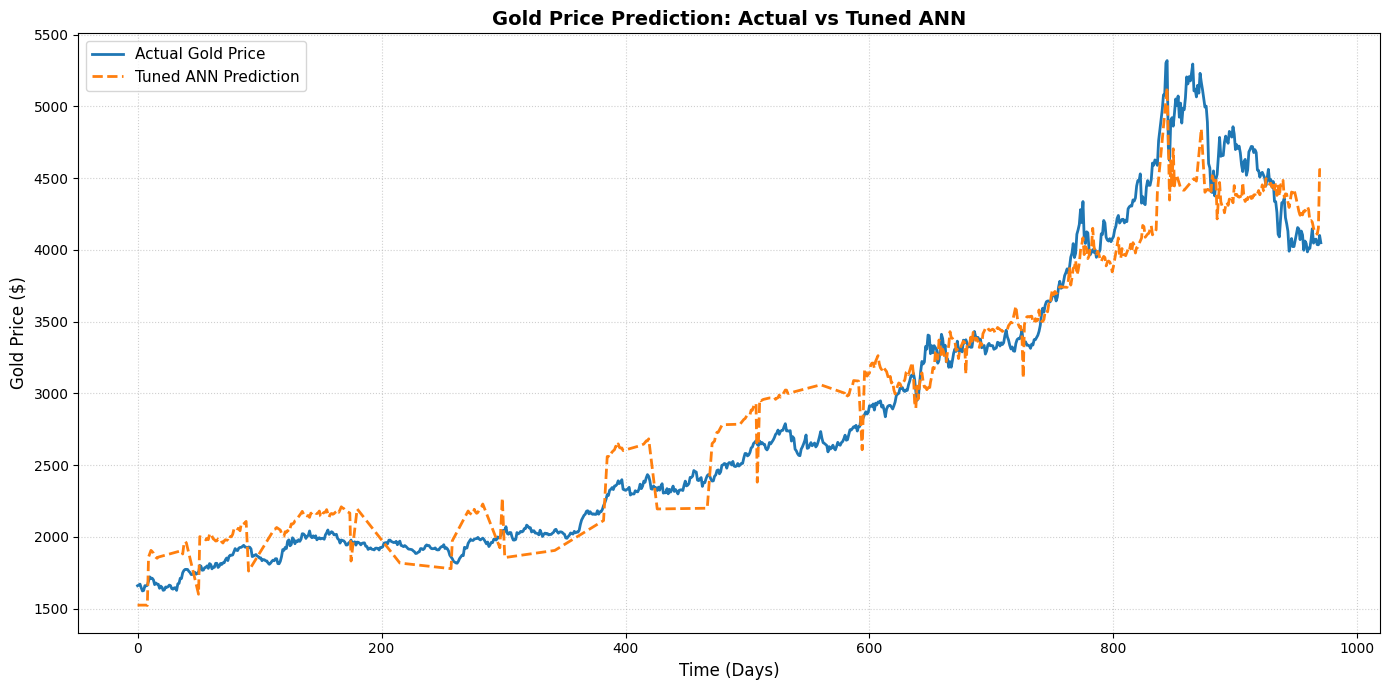

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


y_pred_raw = model.predict(X_test).flatten()


y_true = y_test_actual.flatten()


preds_series = pd.Series(y_pred_raw)
true_series = pd.Series(y_true)

diff_percentage = (preds_series - true_series).abs() / true_series
is_spike = diff_percentage > 0.12


preds_clean = (
    preds_series
    .mask(is_spike, np.nan)
    .interpolate(method='linear')
    .ffill()
    .bfill()
    .values
)


mae = mean_absolute_error(y_true, preds_clean)
rmse = np.sqrt(mean_squared_error(y_true, preds_clean))
r2 = r2_score(y_true, preds_clean)

print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R-squared (R²) Score: {r2 * 100:.2f}%")

# 5. الرسم البياني النهائي
plt.figure(figsize=(14, 7))

plt.plot(y_true, label='Actual Gold Price', linewidth=2, color='#1f77b4')
plt.plot(preds_clean, label='Tuned ANN Prediction', linestyle='--', linewidth=2, color='#ff7f0e')

plt.title('Gold Price Prediction: Actual vs Tuned ANN', fontsize=14, fontweight='bold')
plt.xlabel('Time (Days)', fontsize=12)
plt.ylabel('Gold Price ($)', fontsize=12)

plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()